# Exploratory Data Analysis



1. General Data Information

2. Univariate Analysis
* symmetry
* skewness
* presence of multiple peaks
* range of values

3. Correlation Analysis
* Does study time affect scores?
* Does sleep affect scores?
* Do online courses affect scores?

4. Pairplot

5. Examination of Performance Factors
* Does exam scores increase with study time?
* Do students with more courses achieve higher grades?
* Is there an optimal amount of sleep?

7. Student Segmentation

8. Key Insights & Conclusion

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = r"/Users/sergeygorodinsky/Desktop/py/Student_Perfomance_Analysis/data/processed/students_data.csv"

df = pd.read_csv(path)
df

,daily_study_hours,online_courses_taken,avg_sleep_hours,exam_score
0,3.31,3,6.24,79.44
1,7.63,5,7.00,68.34
2,5.99,2,6.58,92.81
3,4.99,4,8.60,52.94
4,1.67,0,6.48,80.67
...,...,...,...,...
995,1.19,0,7.84,41.83
996,7.38,2,6.08,52.27
997,1.53,2,8.11,60.42
998,7.63,3,8.25,70.63


1. General Data Information

In [74]:
df.shape

(1000, 4)

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   daily_study_hours     1000 non-null   float64
 1   online_courses_taken  1000 non-null   int64  
 2   avg_sleep_hours       1000 non-null   float64
 3   exam_score            1000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [76]:
df.describe()

,daily_study_hours,online_courses_taken,avg_sleep_hours,exam_score
count,1000.00000,1000.00000,1000.000000,1000.000000
mean,4.17710,2.49800,6.499930,69.839840
std,2.19098,1.71258,1.443699,17.274093
min,0.53000,0.00000,4.000000,40.000000
25%,2.27000,1.00000,5.300000,54.847500
50%,4.22500,3.00000,6.505000,69.970000
75%,6.08250,4.00000,7.770000,84.892500
max,8.00000,5.00000,8.990000,99.970000


In [77]:
df.isnull().sum()

daily_study_hours       0
online_courses_taken    0
avg_sleep_hours         0
exam_score              0
dtype: int64

In [78]:
df.nunique()

daily_study_hours       555
online_courses_taken      6
avg_sleep_hours         431
exam_score              903
dtype: int64

2. Univariate Analysis

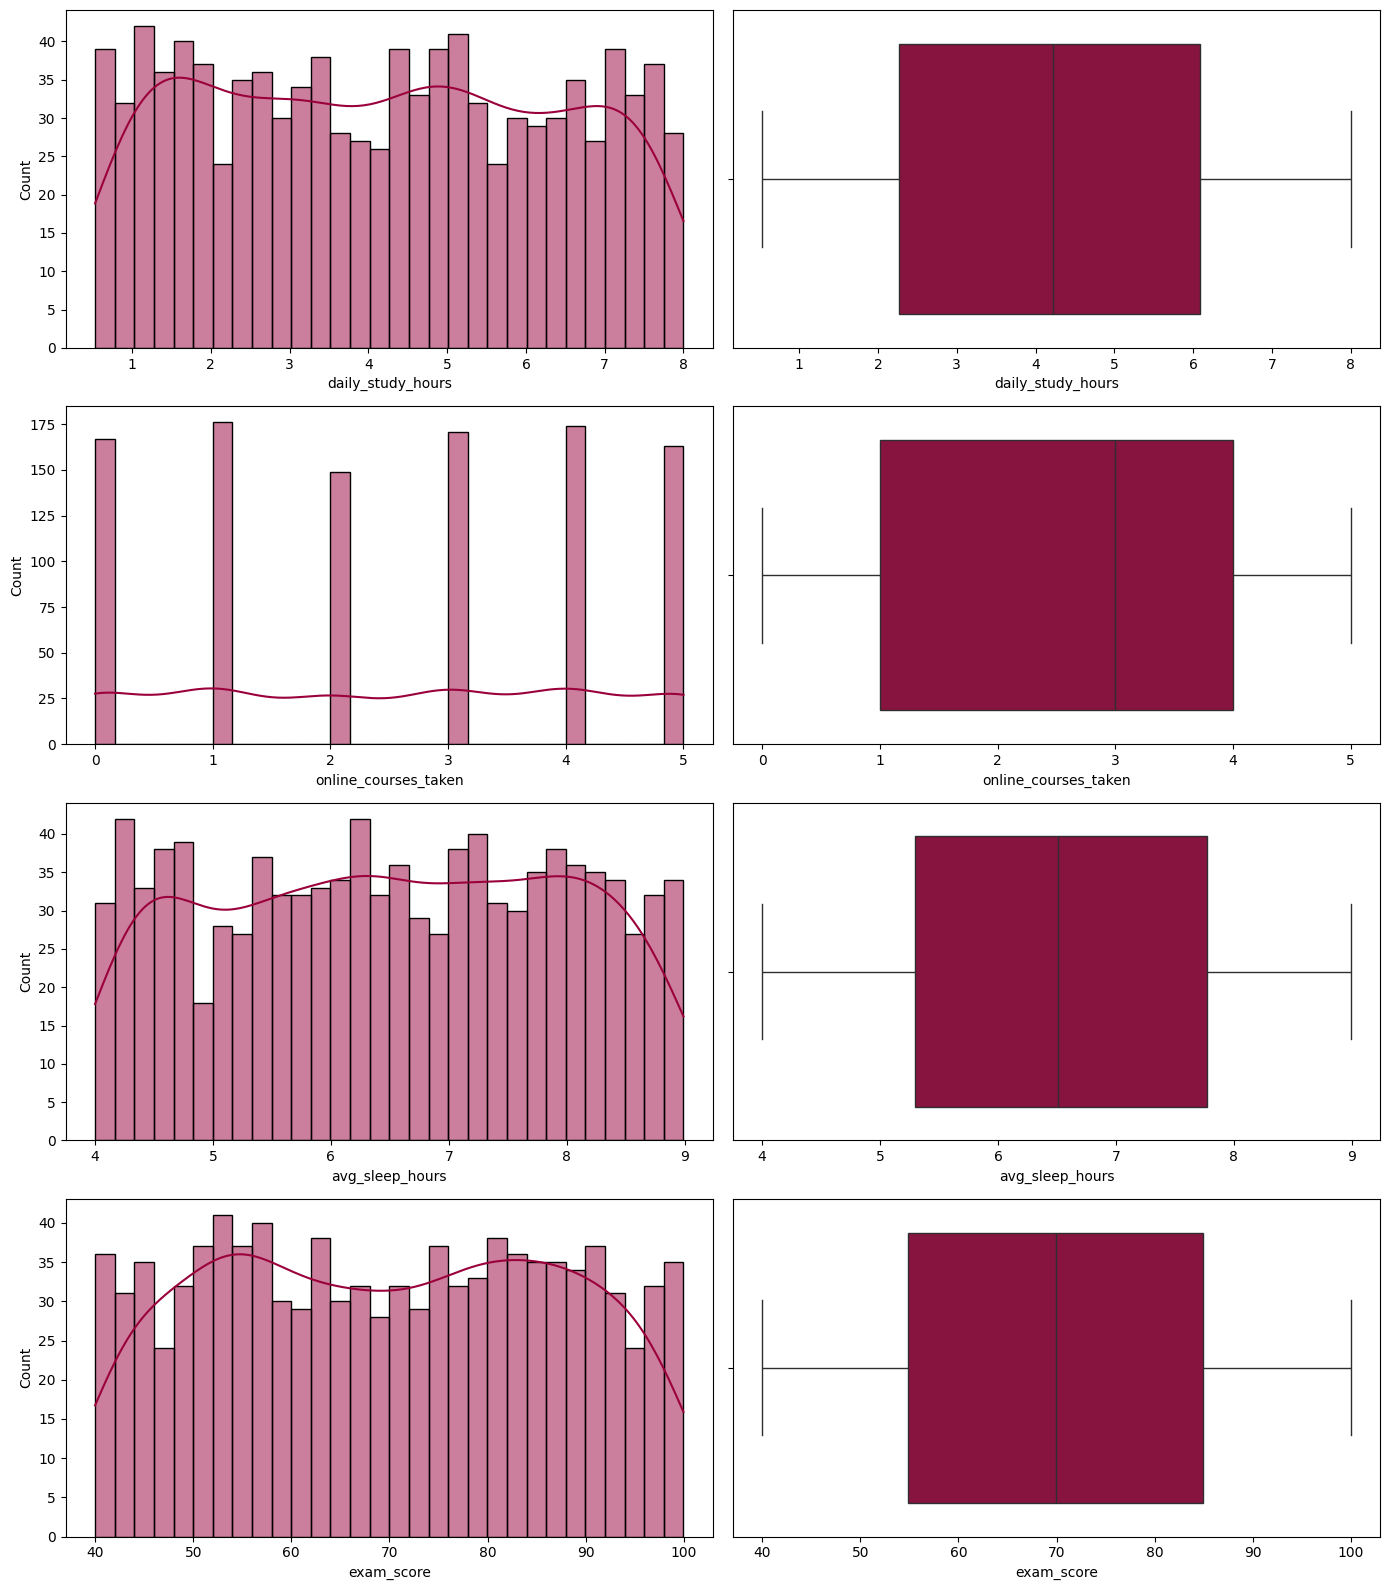

In [79]:
column_names = df.columns

fig,axes = plt.subplots(4, 2, figsize=(14, 16))


# color="#7E0030"
for i,col in enumerate(column_names):
    # Histogram + KDE
    sns.histplot(data=df,x=col,kde=True,ax=axes[i][0],color="#9A003B",bins=30)

    # Boxplot
    sns.boxplot(data=df,x=col,ax=axes[i][1],color="#9A003B")

plt.tight_layout()
plt.show()


#### (1) daily_study_hours
* Uniform distribution - KDE is almost flat, no distinct peak
* Skewness ≈ 0 - symmetrical
* Range: 0.5 - 8 hours
* No outliers

#### (2) online_courses_taken
* Uniform distribution - KDE is flat because data is discrete
* Each value occurs ≈ 150 - 175 times
* No outliers

##### (3) avg_sleep_hours
* Close to normal distribution - slightly bimodal (two small peaks near 5 and 7.5)
* Skewness: Weak left skew, slightly more students sleep less than average.
* Range: 4 - 9 hours
* No outliers

#### (4) exam_score
* Bimodal distribution - two peaks: one around 50–55, the other around 80–85
* Skewness ≈ 0
* Range: 40 - 100
* No outliers


Observations:
* daily_study_hours and online_courses_taken follow a uniform distribution,
  showing that the kaggle dataset was synthetically generated or sampled evenly.

* avg_sleep_hours approximates a normal distribution with a slight left skew.

* exam_score shows a bimodal distribution, pointing at two distinct student
  groups which will be explored in the further analysis.
  
* No outliers were detected across all variables, consistent with the IQR
  check performed during data cleaning.

3. Correlation Analysis

In [80]:
correlations = df.corr()
correlations

,daily_study_hours,online_courses_taken,avg_sleep_hours,exam_score
daily_study_hours,1.000000,0.032983,-0.001034,0.006005
online_courses_taken,0.032983,1.000000,0.010545,0.003909
avg_sleep_hours,-0.001034,0.010545,1.000000,-0.003493
exam_score,0.006005,0.003909,-0.003493,1.000000


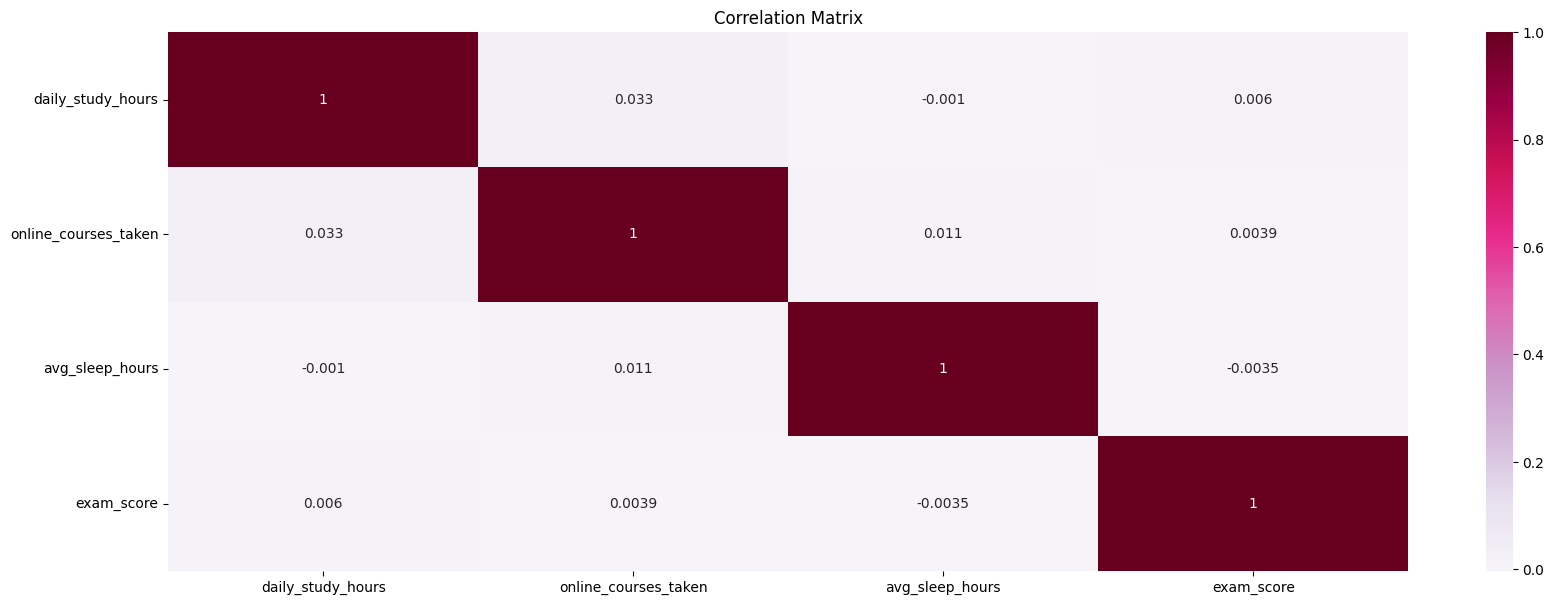

In [81]:
sns.heatmap(correlations,annot=True,cmap="PuRd")
plt.rcParams["figure.figsize"] = (20,7)
plt.title("Correlation Matrix")
plt.show()

Observations:
* No meaningful linear correlation was found between any feature indicating that study hours,
sleep, and online courses individually cannot predict exam performance through a linear relationship.

* Features are also independent from each other confirming no multicollinearity.

This does not mean these features are irrelevant though. The bimodal distribution
of exam_score (found in Univariate Analysis) suggests a non-linear pattern.
Segmentation analysis may reveal what separates high and low performers.


4. Pairplot

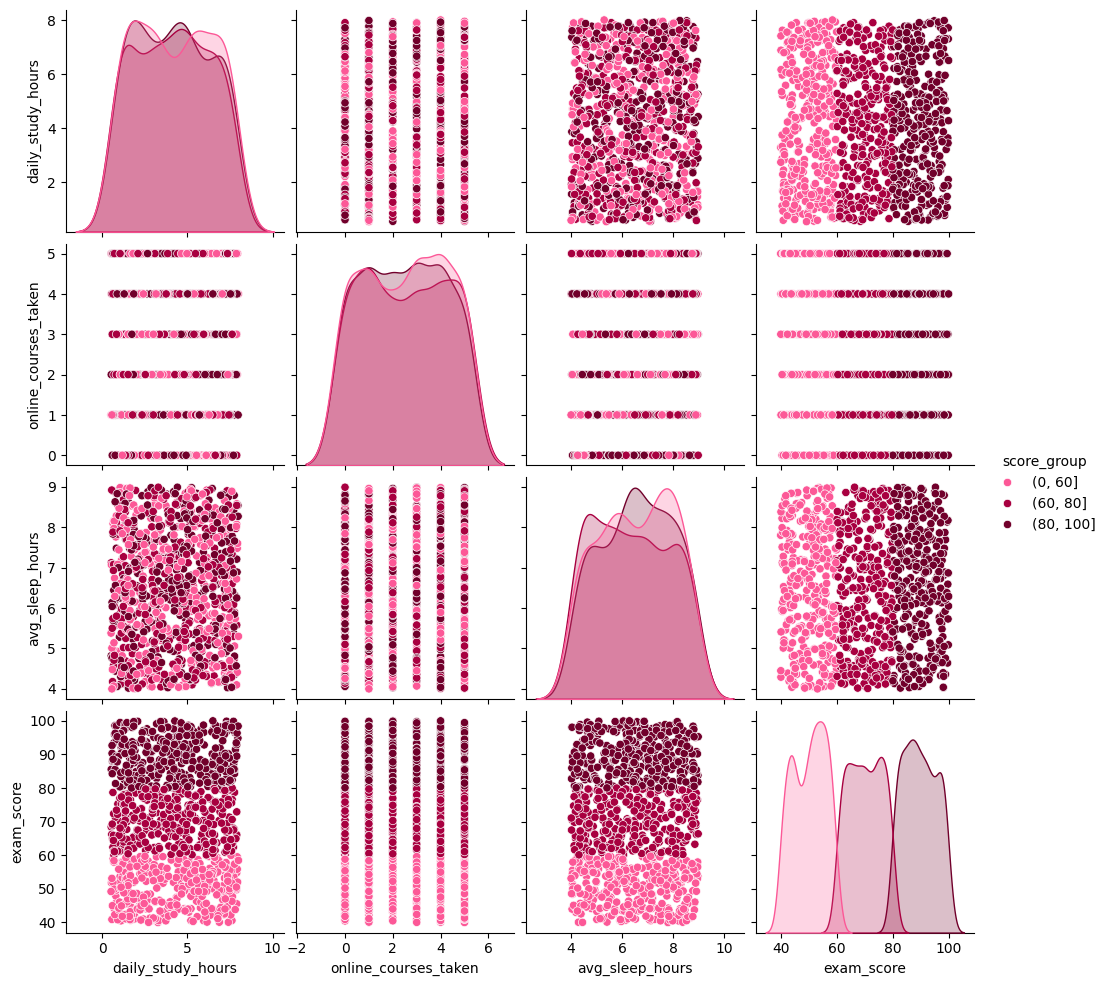

In [82]:
df["score_group"] = pd.cut(df["exam_score"],bins=[0,60,80,100])

sns.pairplot(data=df,diag_kind="kde",hue="score_group",palette=["#FC5897","#A80040","#71002B"])

plt.show()

Observations:
* All scatter plots show completely mixed color groups - no feature separates Low, Medium, and High performers.This confirms information from the correlation matrix: study hours, sleep, and online courses are equally distributed across all score groups.


* The KDE diagonal reveals that avg_sleep_hours is bimodal across all groups, suggesting sleep patterns are independent of performance.


* Conclusion: individual features alone cannot explain exam score.The dataset was generated independently of these features.

5. Examination of Performance Factors

* Does exam scores increase with study time?

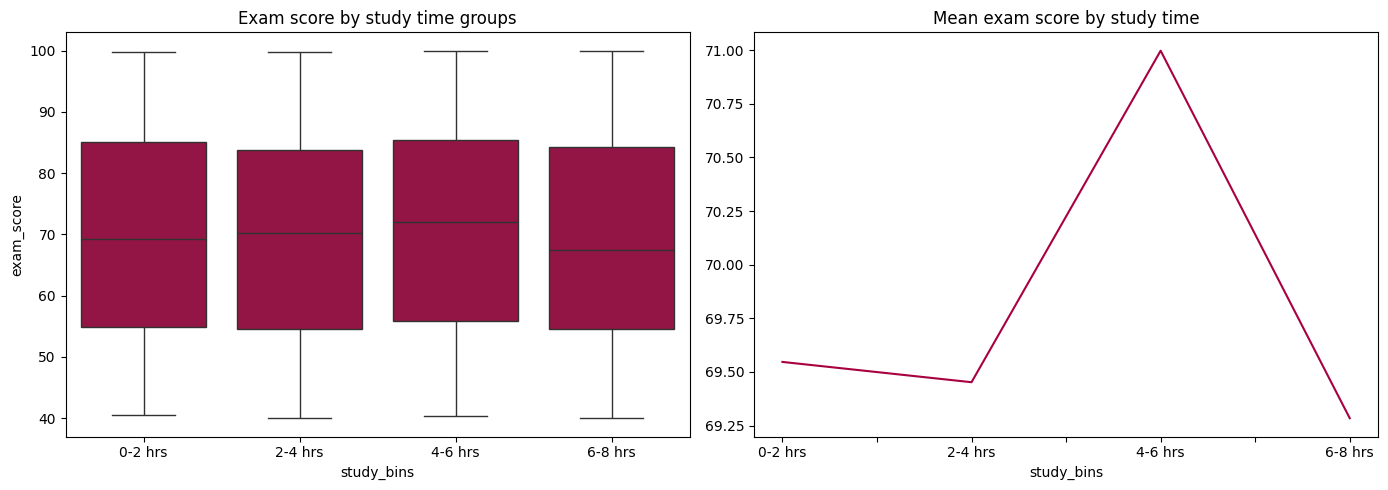

In [83]:
df["study_bins"] = pd.cut(df["daily_study_hours"],bins = [0,2,4,6,8],labels=["0-2 hrs", "2-4 hrs", "4-6 hrs", "6-8 hrs"],)

fig, axes = plt.subplots(1,2, figsize = (14,5))

sns.boxplot(data = df, x="study_bins", y="exam_score", ax=axes[0],color="#A80040")
axes[0].set_title("Exam score by study time groups")

df.groupby("study_bins", observed=True)["exam_score"].mean().plot(kind="line", ax=axes[1],color="#A80040")
axes[1].set_title("Mean exam score by study time")

plt.tight_layout()
plt.show()

Does exam score increase with study time?
Answer: No

Mean exam scores across study groups range from 69.5 to 71.0 - 
a difference of only 1.5 points. Boxplots show near-identical 
distributions across all groups.

Study time has no meaningful effect on exam performance in this dataset.
This is consistent with datasat being synthetic

* Do students with more courses achieve higher grades?

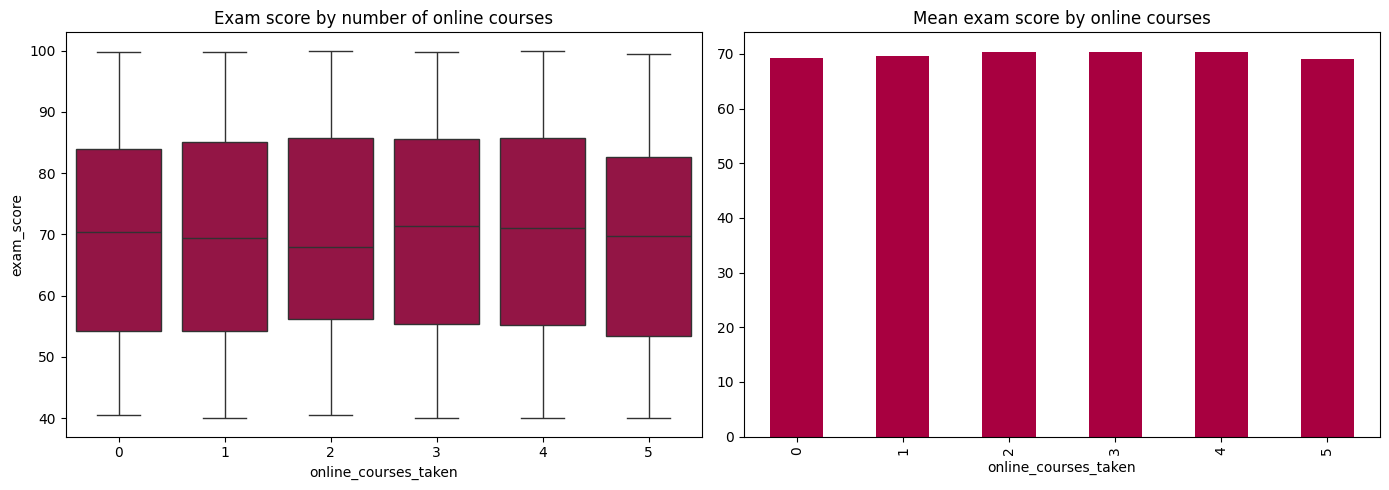

In [84]:
fig, axes = plt.subplots(1,2, figsize = (14,5))

sns.boxplot(data = df, x="online_courses_taken", y="exam_score", ax=axes[0], color="#A80040")
axes[0].set_title("Exam score by number of online courses")


# sns.lineplot(data = df, x="online_courses_taken", y="exam_score", ax=axes[1], color="#A80040")
df.groupby("online_courses_taken")["exam_score"].mean().plot(kind="bar",ax=axes[1],color="#A80040")
axes[1].set_title("Mean exam score by online courses")



plt.tight_layout()
plt.show()

Do students with more courses achieve higher grades?
Answer: No.

Average exam scores are virtually identical across all courses. Students who take 0 courses perform similarly to students who take 5 courses.

The number of online courses does not affect exam scores.
This is consistent with correlation analysis.

* Is there an optimal amount of sleep?

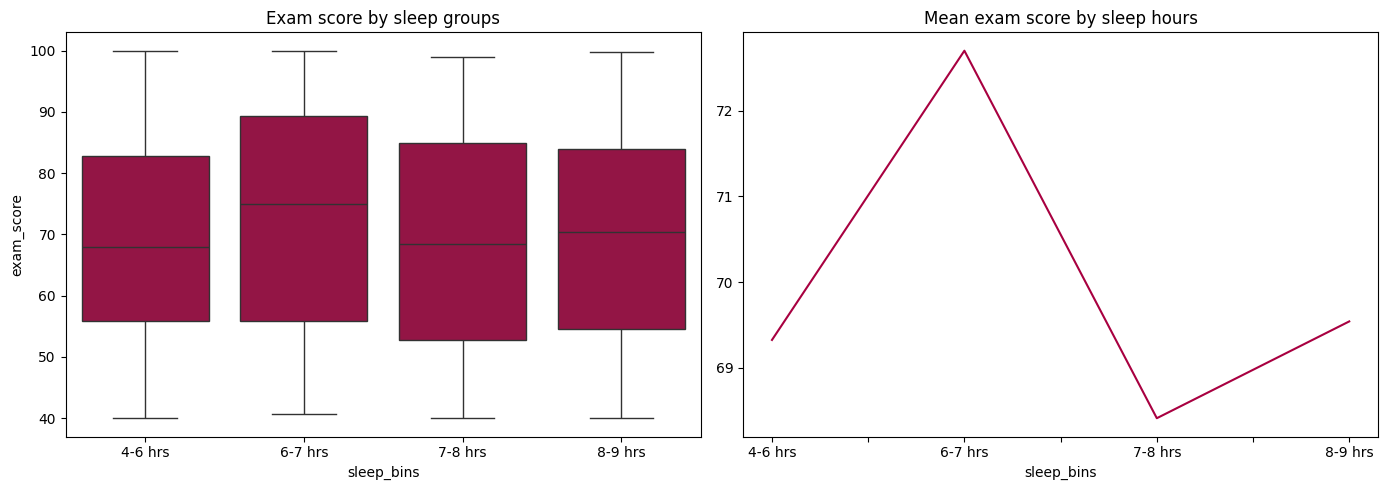

In [85]:
df["sleep_bins"] = pd.cut(df["avg_sleep_hours"], bins=[4,6,7,8,9],labels=["4-6 hrs", "6-7 hrs", "7-8 hrs", "8-9 hrs"])
fig, axes = plt.subplots(1,2, figsize = (14,5))

sns.boxplot(data=df, x="sleep_bins",y="exam_score",ax=axes[0],color="#A80040")
axes[0].set_title("Exam score by sleep groups")

df.groupby("sleep_bins", observed=True)["exam_score"].mean().plot(kind="line", ax=axes[1],color="#A80040")
axes[1].set_title("Mean exam score by sleep hours")


plt.tight_layout()
plt.show()

Is there an optimal amount of sleep?
Answer: No clear evidence.

The line chart appears to show a peak at 6-7 hours,
but this is misleading - the difference between groups is only 3.5 
points. Boxplots show heavily overlapping distributions across all 
sleep groups.

The apparent peak at 6-7 hrs is likely due to random variation 
rather than a true effect.

7. Student Segmentation

In [86]:
df.columns

Index(['daily_study_hours', 'online_courses_taken', 'avg_sleep_hours',
       'exam_score', 'score_group', 'study_bins', 'sleep_bins'],
      dtype='str')

In [87]:
df["exam_score"].describe()

count    1000.000000
mean       69.839840
std        17.274093
min        40.000000
25%        54.847500
50%        69.970000
75%        84.892500
max        99.970000
Name: exam_score, dtype: float64

In [88]:
df["segments"] = pd.cut(df["exam_score"], bins = [40,60,80,100],
            labels = ["Low (40-60)", "Medium (61-80)", "High (81-100)"])

df["segments"].value_counts()

segments
Low (40-60)       342
High (81-100)     335
Medium (61-80)    322
Name: count, dtype: int64

In [89]:
profile = df.groupby("segments",observed=True)[['daily_study_hours', 'online_courses_taken', 'avg_sleep_hours',
       'exam_score']].mean().round(2)
profile

,daily_study_hours,online_courses_taken,avg_sleep_hours,exam_score
segments,,,,
Low (40-60),4.23,2.51,6.54,50.22
Medium (61-80),4.14,2.51,6.37,70.15
High (81-100),4.17,2.47,6.58,89.66


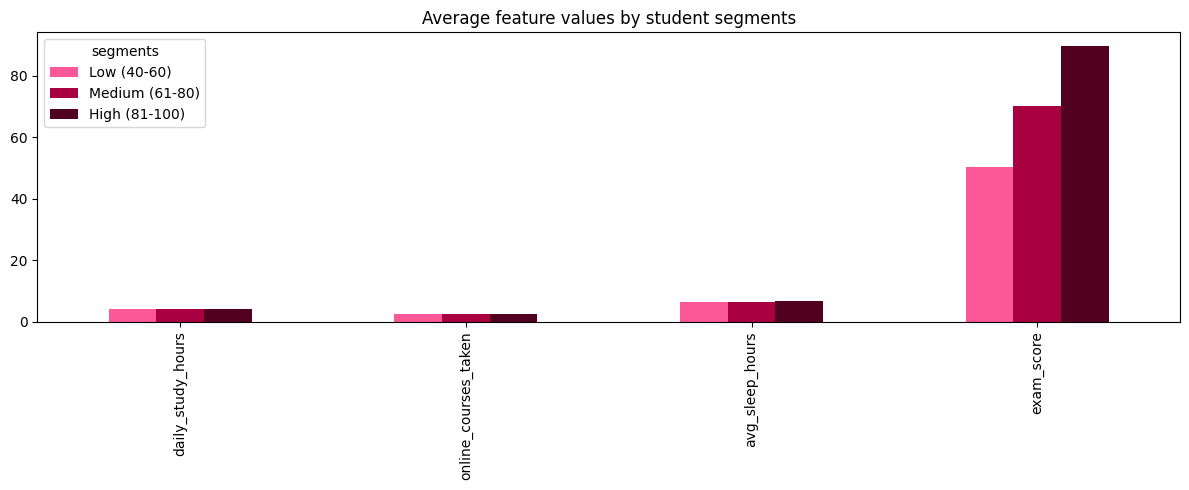

In [90]:
profile.T.plot(kind="bar",figsize=(12,5),color=["#FC5897","#A80040","#52001F"])
plt.title('Average feature values by student segments')



plt.tight_layout()
plt.show()

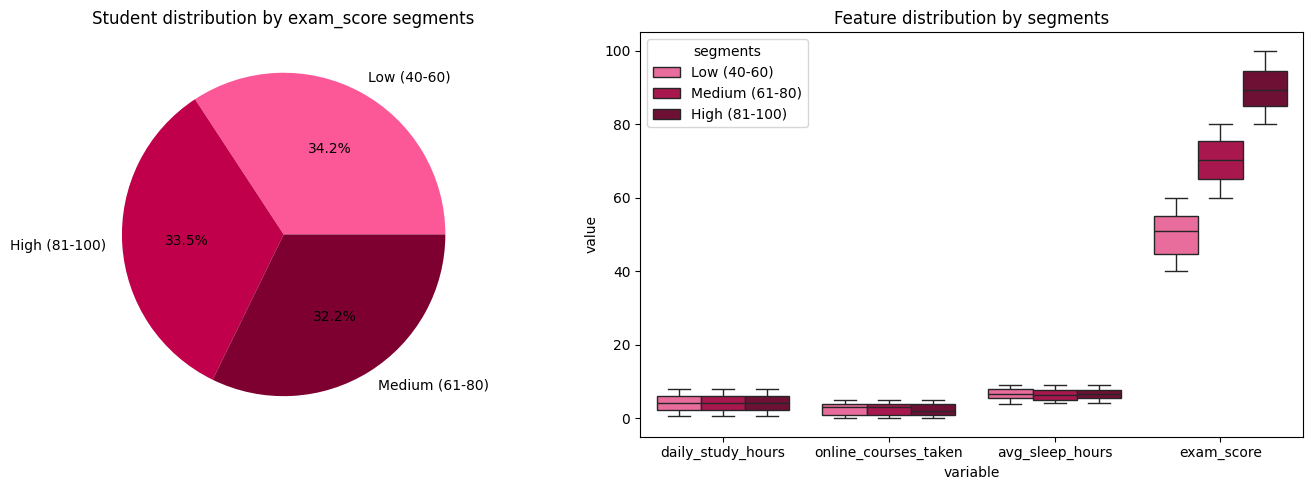

In [91]:
fig, axes = plt.subplots(1,2, figsize = (14,5))
df["segments"].value_counts().plot(kind="pie",ax=axes[0], colors=["#FC5897","#C0004A","#7E0030"],autopct="%1.1f%%")
axes[0].set_title("Student distribution by exam_score segments")

df_melt = df.melt(id_vars="segments", value_vars=['daily_study_hours', 'online_courses_taken', 'avg_sleep_hours',
       'exam_score'])
sns.boxplot(data=df_melt, x='variable', y='value', hue="segments", ax=axes[1],palette=["#FC5897","#C0004A","#7E0030"])
axes[1].set_title("Feature distribution by segments")


plt.tight_layout()
plt.show()


The near-equal distribution across segments is not typical 
for real academic data and supports the conclusion that 
exam_score was generated independently of the other features.There is no feature combination that distinguishes high performers  from low performers in this dataset.

Conclusion: The measured features (study habits, sleep, online courses)
do not explain exam performance. Either important features are missing
from the dataset, or exam_score was generated independently -
consistent with all prior analysis sections.

## 8. Key Insights & Conclusion

### What was found:
1. **No linear correlations** - No correlation between
   features and exam_score. Study time, sleep, and online courses
   show no measurable linear effect on performance.

2. **Bimodal exam_score distribution** - two distinct peaks near 50
   and 80 suggest two student groups, but segmentation analysis
   showed these groups are identical in their study habits and sleep.

3. **Uniform feature distributions** - daily_study_hours and
   online_courses_taken are uniformly distributed, which is atypical
   for real academic data.

4. **Equal segment sizes** - Low/Medium/High performers each
   represent around 33% of students, further confirming artificial data
   generation.

### Main conclusion:
The dataset appears to be synthetically generated. Exam scores are
statistically independent of the measured features. A real-world
dataset would likely show at least moderate correlations between
study time and academic performance.

### Limitations:
- Dataset is likely synthetic - findings may not generalize
- Sample size of 1000 is adequate but larger samples would
reduce uncertainty in group comparisons